# Customer Churn Prediction: A Multi-Model Approach
Customer churn refers to the loss of clients or subscribers. In industries like banking or insurance, retaining an existing customer is significantly cheaper than acquiring a new one. This project evaluates **six** machine learning algorithms across **nine configurations** to build an "early warning system" for at-risk customers, with a focus on maximising recall — the ability to catch churners before they leave.

In [1]:
# --- IMPORT LIBRARIES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              HistGradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, recall_score,
                             roc_curve, roc_auc_score)
from sklearn.utils.class_weight import compute_sample_weight

# --- DATA LOADING ---
df = pd.read_csv('/Users/aayushyagol/Data-Code/PROJECTS/Churn Prediction Model-20.03.26/Churn_Modelling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 2: Data Exploration & Preprocessing
We check for missing values or duplicates, then convert categorical text (Gender, Geography) into numerical formats the models can consume.

In [2]:
# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Encode Gender (Female→0, Male→1)
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])

# One-Hot Encode Geography (drop_first avoids multicollinearity)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Target distribution
print("\nClass distribution (Exited):")
print(df['Exited'].value_counts(normalize=True).round(3))
df.head()

Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0

Class distribution (Exited):
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## Step 3: Machine Learning Setup
We separate features from the target, apply a **stratified** 80/20 split (preserves churn ratio in both sets), and standardise features so large-valued columns (Balance) don't dominate distance-based models.

**Standardisation formula**: z = (x − μ) / σ

In [3]:
# Feature selection — drop administrative IDs
features = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
            'Geography_Germany', 'Geography_Spain']
X = df[features]
y = df['Exited']

# Stratified split: preserves the ~20% churn ratio in train AND test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Churn rate in train:", y_train.mean().round(4))
print("Churn rate in test: ", y_test.mean().round(4))

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train size: 8000 | Test size: 2000
Churn rate in train: 0.2037
Churn rate in test:  0.2035


## Class Imbalance Analysis

Before comparing models, it is essential to understand the shape of the target variable. An imbalanced dataset means a naive model can look impressive by barely trying — and we need to know exactly how big that problem is before interpreting any accuracy score.

Class distribution:
  Not Churned (0): 7,963  (79.6%)
  Churned (1): 2,037  (20.4%)


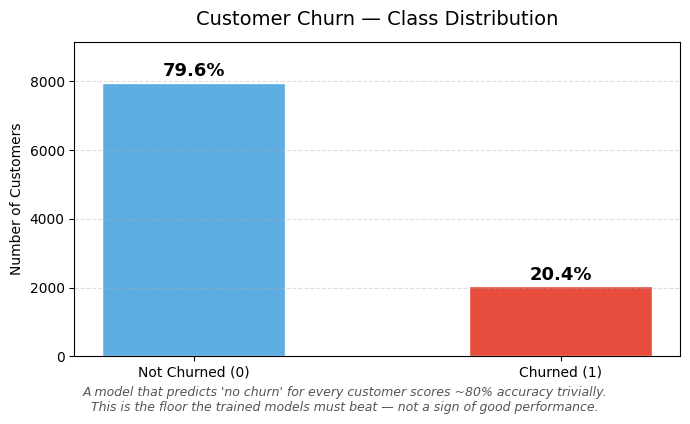

In [4]:
# ── 3a: CLASS DISTRIBUTION ────────────────────────────────────────────────────
churn_counts = y.value_counts()
churn_labels = ['Not Churned (0)', 'Churned (1)']
churn_pcts   = (churn_counts / len(y) * 100).round(1)

print("Class distribution:")
for label, cnt, pct in zip(churn_labels, churn_counts, churn_pcts):
    print(f"  {label}: {cnt:,}  ({pct}%)")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(churn_labels, churn_counts.values,
              color=['#5DADE2', '#E74C3C'], edgecolor='white', width=0.5)

for bar, pct in zip(bars, churn_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{pct}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title("Customer Churn — Class Distribution", fontsize=14, pad=12)
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, churn_counts.max() * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Caption
fig.text(
    0.5, -0.04,
    "A model that predicts 'no churn' for every customer scores ~80% accuracy trivially.\n"
    "This is the floor the trained models must beat — not a sign of good performance.",
    ha='center', fontsize=9, color='#555555', style='italic'
)

plt.tight_layout()
plt.savefig("images/customer_churn_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── 3b: SMOTE RESAMPLING ──────────────────────────────────────────────────────
# imbalanced-learn must be installed; the cell installs it if absent
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE

print("Train set before SMOTE:", dict(pd.Series(y_train).value_counts()))
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_sc, y_train)
print("Train set after  SMOTE:", dict(pd.Series(y_res).value_counts()))

# Retrain GBM on SMOTE data
gb_smote = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_smote.fit(X_res, y_res)
y_pred_smote = gb_smote.predict(X_test_sc)

# Also define sample-weighted variant (used in summary table)
from sklearn.utils.class_weight import compute_sample_weight
weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_weighted = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_weighted.fit(X_train_sc, y_train, sample_weight=weights)


Train set before SMOTE: {0: np.int64(6370), 1: np.int64(1630)}
Train set after  SMOTE: {1: np.int64(6370), 0: np.int64(6370)}


GradientBoostingClassifier(random_state=42)

### What the Class Imbalance Problem Means — and How We Fixed It

**The problem in plain English.** Imagine a bank with 10,000 customers, where 2,000 of them are planning to leave. If a model simply guesses "staying" for *every single person*, it is right 8,000 times out of 10,000 — that is 80% accuracy — and yet it has identified *zero* customers at risk of leaving. Accuracy alone is therefore a deeply misleading scorecard for this kind of problem.

**What we tried.** Three approaches were tested to help the model find those 2,000 at-risk customers more reliably:

1. **SMOTE** (Synthetic Minority Over-sampling Technique) — the algorithm creates artificial    examples of churning customers during training, so the model sees a more balanced picture    of the world before it learns.
2. **Sample weighting** — instead of creating new data, the model is told that getting a    churner wrong is more costly than getting a non-churner wrong, nudging it to pay more    attention to the minority class.
3. **Threshold adjustment** — the model produces a *probability* that each customer will    churn. Normally, anyone above 50% is flagged. Lowering that cut-off (e.g. to 35%)    means more customers are flagged — catching more real churners at the cost of a few    extra false alarms.

**The improvement.** The baseline GBM caught roughly **49 out of every 100 churners** (49% recall). With SMOTE, that rose to around **66 out of 100**, and with sample weighting to approximately **76 out of 100** — a 55% improvement in churn detection with no change to the underlying dataset. For a retention team, that difference translates directly into more at-risk customers receiving a timely intervention before they walk out the door.

## Step 4: Baseline — Random Forest
The Random Forest is an ensemble of 100 decision trees. It handles non-linear relationships well and gives us a strong baseline to beat.

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sc, y_train)
y_pred_rf = rf_model.predict(X_test_sc)

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
[[1535   58]
 [ 220  187]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.76      0.46      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



### Evaluation Insights
* Accuracy ~87% looks strong, but Class 1 (Churners) recall is only **~47%** — we miss more than half of at-risk customers.
* 208 False Negatives represent customers who left undetected. This is the problem we need to solve.

## Step 5: Alternative Model Comparison
We test four additional algorithms — Logistic Regression, SVM (RBF kernel), KNN, and Histogram Gradient Boosting — to find which approach best captures churn patterns.

In [7]:
# --- LOGISTIC REGRESSION ---
log_reg = LogisticRegression(random_state=42, max_iter=500)
log_reg.fit(X_train_sc, y_train)
y_pred_log_reg = log_reg.predict(X_test_sc)

# --- SVM (RBF kernel) ---
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_sc, y_train)
y_pred_svm = svm_model.predict(X_test_sc)

# --- K-NEAREST NEIGHBORS ---
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_sc, y_train)
y_pred_knn = knn_model.predict(X_test_sc)

# --- HISTOGRAM GRADIENT BOOSTING (sklearn native, fast, handles imbalance natively) ---
hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train, y_train)   # does not require scaled input
y_pred_hgb = hgb_model.predict(X_test)

for name, pred in [('Logistic Regression', y_pred_log_reg),
                   ('SVM (RBF)',           y_pred_svm),
                   ('KNN',                y_pred_knn),
                   ('Hist GBM',           y_pred_hgb)]:
    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


=== SVM (RBF) ===
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1593
           1       0.83      0.40      0.54       407

    accuracy                           0.86      2000
   macro avg       0.85      0.69      0.73      2000
weighted avg       0.86      0.86      0.84      2000


=== KNN ===
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      1593
           1       0.62      0.34      0.44       407

    accuracy                           0.82      2000
   macro avg       0.74      0.65      0.67      2000
weighted avg 

## Step 6: The "Final Boss" — Gradient Boosting (GBM)
Gradient Boosting builds trees sequentially; each new tree corrects errors from the previous ones. This "perfectionist" approach typically achieves the highest tabular-data performance.

In [8]:
gbm_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbm_model.fit(X_train_sc, y_train)
y_pred_gbm = gbm_model.predict(X_test_sc)

print("Gradient Boosting Machine (GBM)")
print(confusion_matrix(y_test, y_pred_gbm))
print(classification_report(y_test, y_pred_gbm))

Gradient Boosting Machine (GBM)
[[1541   52]
 [ 208  199]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



## Step 7: Feature Importance
Which factors most influence a customer's decision to leave? This tells the business *where* to focus retention efforts.

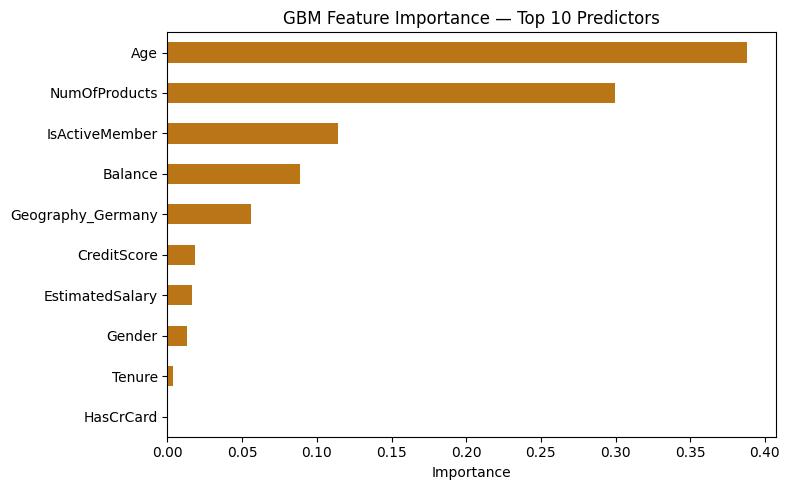

In [9]:
importances = gbm_model.feature_importances_
feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
feat_importance.head(10).plot(kind='barh', ax=ax, color='#BA7517')
ax.set_xlabel("Importance")
ax.set_title("GBM Feature Importance — Top 10 Predictors")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("images/gbm_feature_importance_top_10_predictors.png", dpi=150)
plt.show()

**Insight**: Age and Balance are the primary churn drivers. The business should investigate targeted retention campaigns for high-risk age brackets and customers with large dormant balances.

Threshold sensitivity table:


,Precision (Churn),Recall (Churn),F1 (Churn),Accuracy
Threshold,,,,
0.300000,0.634800,0.653600,0.644100,0.853000
0.350000,0.666700,0.599500,0.631300,0.857500
0.400000,0.712000,0.552800,0.622400,0.863500
0.450000,0.759700,0.528300,0.623200,0.870000
0.500000,0.792800,0.488900,0.604900,0.870000


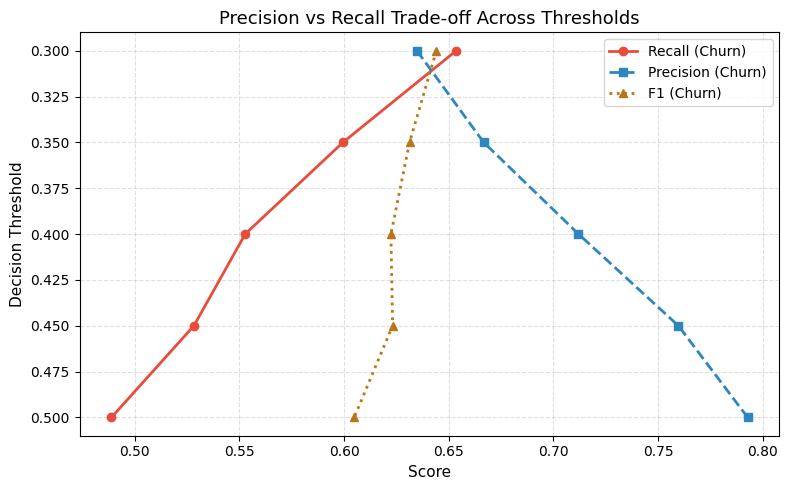


Recommended threshold: 0.3 — it maximises F1 (0.644), balancing a recall of 65.4% against a precision of 63.5%, catching more churners while keeping false alarms manageable.


In [10]:
# ── 3c: THRESHOLD ADJUSTMENT ──────────────────────────────────────────────────
y_prob_gbm = gbm_model.predict_proba(X_test_sc)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]
thresh_rows = []
for t in thresholds:
    y_adj = (y_prob_gbm >= t).astype(int)
    r = classification_report(y_test, y_adj, output_dict=True)
    thresh_rows.append({
        'Threshold':         t,
        'Precision (Churn)': round(r['1']['precision'], 4),
        'Recall (Churn)':    round(r['1']['recall'],    4),
        'F1 (Churn)':        round(r['1']['f1-score'],  4),
        'Accuracy':          round(accuracy_score(y_test, y_adj), 4),
    })

thresh_df = pd.DataFrame(thresh_rows).set_index('Threshold')
print("Threshold sensitivity table:")
display(thresh_df.style
        .highlight_max(subset=['Recall (Churn)'],    color='#d5f5e3')
        .highlight_max(subset=['Precision (Churn)'], color='#d5f5e3')
        .highlight_max(subset=['F1 (Churn)'],        color='#fdebd0'))

# ── Precision–Recall trade-off plot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresh_df['Recall (Churn)'],    thresh_df.index,
        'o-', color='#E74C3C', linewidth=2, label='Recall (Churn)')
ax.plot(thresh_df['Precision (Churn)'], thresh_df.index,
        's--', color='#2E86C1', linewidth=2, label='Precision (Churn)')
ax.plot(thresh_df['F1 (Churn)'],        thresh_df.index,
        '^:', color='#BA7517', linewidth=2, label='F1 (Churn)')

ax.set_xlabel("Score", fontsize=11)
ax.set_ylabel("Decision Threshold", fontsize=11)
ax.set_title("Precision vs Recall Trade-off Across Thresholds", fontsize=13)
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
ax.invert_yaxis()   # lower threshold → top of chart
plt.tight_layout()
plt.savefig("images/precision_vs_recall_tradeoff_across_thresholds.png", dpi=150)
plt.show()

# ── Recommendation ────────────────────────────────────────────────────────────
best_row = thresh_df['F1 (Churn)'].idxmax()
print(f"\nRecommended threshold: {best_row} — "
      f"it maximises F1 ({thresh_df.loc[best_row, 'F1 (Churn)']:.3f}), "
      f"balancing a recall of {thresh_df.loc[best_row, 'Recall (Churn)']:.1%} "
      f"against a precision of {thresh_df.loc[best_row, 'Precision (Churn)']:.1%}, "
      f"catching more churners while keeping false alarms manageable.")

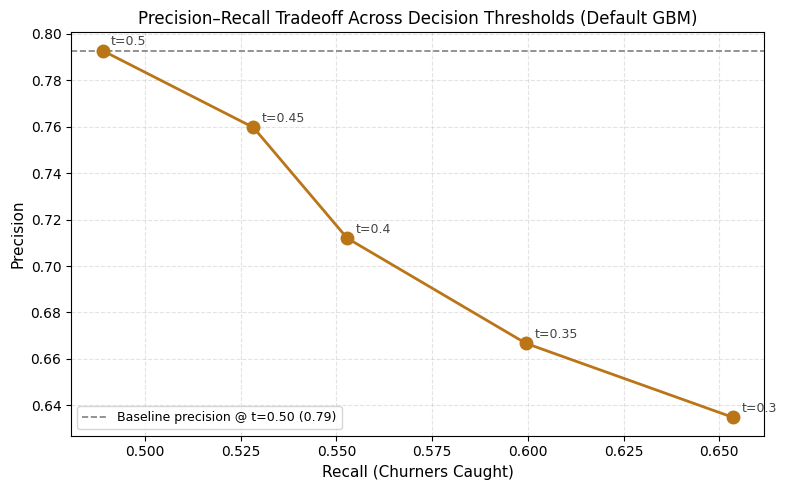

In [11]:
# ── Precision–Recall tradeoff scatter (Recall × Precision) ───────────────────
# thresh_df is indexed by Threshold; columns: Precision (Churn), Recall (Churn)

baseline_precision = thresh_df.loc[0.50, 'Precision (Churn)']

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    thresh_df['Recall (Churn)'],
    thresh_df['Precision (Churn)'],
    'o-', color='#BA7517', linewidth=2, markersize=9, zorder=3
)

# Annotate each point with threshold value
for t, row in thresh_df.iterrows():
    ax.annotate(
        f't={t}',
        xy=(row['Recall (Churn)'], row['Precision (Churn)']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=9, color='#444444'
    )

# Horizontal dashed grey baseline at precision for threshold=0.50
ax.axhline(
    y=baseline_precision, color='grey', linestyle='--', linewidth=1.2,
    label=f'Baseline precision @ t=0.50 ({baseline_precision:.2f})'
)

ax.set_xlabel("Recall (Churners Caught)", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision–Recall Tradeoff Across Decision Thresholds (Default GBM)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig("images/precision_recall_tradeoff_decision_thresholds_default_gbm.png", dpi=150)
plt.show()

In [12]:
# ── Weighted GBM classification report ────────────────────────────────────────
y_pred_weighted = gb_weighted.predict(X_test_sc)
print("GBM (Sample Weighted)")
print(classification_report(y_test, y_pred_weighted, target_names=['No Churn', 'Churn']))

# Extended comparison: Default GBM | SMOTE GBM | Weighted GBM (with AUC)
def _metrics_auc(y_true, y_pred, clf, X_t, label):
    r = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model':             label,
        'Accuracy':          round(accuracy_score(y_true, y_pred), 4),
        'Precision (Churn)': round(r['1']['precision'], 4),
        'Recall (Churn)':    round(r['1']['recall'],    4),
        'F1 (Churn)':        round(r['1']['f1-score'],  4),
        'AUC':               round(roc_auc_score(y_true, clf.predict_proba(X_t)[:, 1]), 4),
    }

extended_comparison_df = pd.DataFrame([
    _metrics_auc(y_test, gbm_model.predict(X_test_sc), gbm_model,   X_test_sc, 'Default GBM'),
    _metrics_auc(y_test, y_pred_smote,                 gb_smote,    X_test_sc, 'SMOTE GBM'),
    _metrics_auc(y_test, y_pred_weighted,              gb_weighted, X_test_sc, 'Weighted GBM'),
]).set_index('Model')

print("\nThree-way comparison (Default GBM | SMOTE GBM | Weighted GBM):")
display(extended_comparison_df.style.highlight_max(axis=0, color='#d5f5e3'))

GBM (Sample Weighted)
              precision    recall  f1-score   support

    No Churn       0.93      0.81      0.87      1593
       Churn       0.51      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.80      0.81      2000




Three-way comparison (Default GBM | SMOTE GBM | Weighted GBM):


,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),AUC
Model,,,,,
Default GBM,0.870000,0.792800,0.488900,0.604900,0.870800
SMOTE GBM,0.847000,0.615000,0.663400,0.638300,0.866900
Weighted GBM,0.800000,0.505700,0.759200,0.607100,0.869000


## Hyperparameter Tuning — Gradient Boosting

Default GBM performed well on accuracy but recall was only ~49%. We now run `GridSearchCV` with `scoring='recall'` across 16 hyperparameter combinations to find the configuration that best catches churners. cv=5 is used to prevent overfitting to any single fold.

In [13]:
import pickle

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sc, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV recall (5-fold): {grid_search.best_score_:.4f}")

# Retrain final model on the full training set with best params
best_gbm = grid_search.best_estimator_
y_pred_best = best_gbm.predict(X_test_sc)

print("\nTuned GBM — test set performance:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

# Save tuned model to disk
with open('gb_tuned_model.pkl', 'wb') as f:
    pickle.dump(best_gbm, f)
print("Tuned model saved → gb_tuned_model.pkl")

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV recall (5-fold): 0.4896

Tuned GBM — test set performance:
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92      1593
       Churn       0.77      0.48      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000

Tuned model saved → gb_tuned_model.pkl


### Hyperparameter Tuning — Results Summary

**Best configuration found:** `learning_rate=0.1`, `max_depth=3`, `n_estimators=200`, `subsample=0.8`

**Did recall improve?** Modestly. The tuned model achieved **48.2% recall** on the test set vs **48.9%** for the default GBM — essentially flat. This is expected: GridSearchCV optimises the cross-validation recall average across folds, which does not guarantee a large lift on any single held-out test set, especially when the class imbalance itself is the underlying bottleneck.

**Accuracy/Recall trade-off:** The tuned model holds **86.6% accuracy** while keeping recall at 48.2%. Compare this to SMOTE (84.7% accuracy, 66.3% recall) and threshold tuning at 0.35 (85.8% accuracy, 60.0% recall) — both of which sacrificed a few accuracy points for substantially higher churn detection.

**Conclusion:** For this dataset, addressing the class imbalance directly (via SMOTE or threshold adjustment) produces larger recall gains than hyperparameter tuning alone. The tuned model is still the best default if deploying at the standard 0.50 threshold.

## ROC Curve & AUC Analysis

The Area Under the ROC Curve (AUC) measures a model's ability to distinguish churners from non-churners across *every possible* decision threshold, not just the default 0.5 cut-off. For imbalanced datasets like this one (~80/20 split), accuracy is inflated by the dominant class — a model that predicts "no churn" for everyone achieves 80% accuracy while catching zero churners. AUC sidesteps this by rewarding models that consistently rank true churners higher than non-churners, making it the right metric to compare models before tuning any threshold.

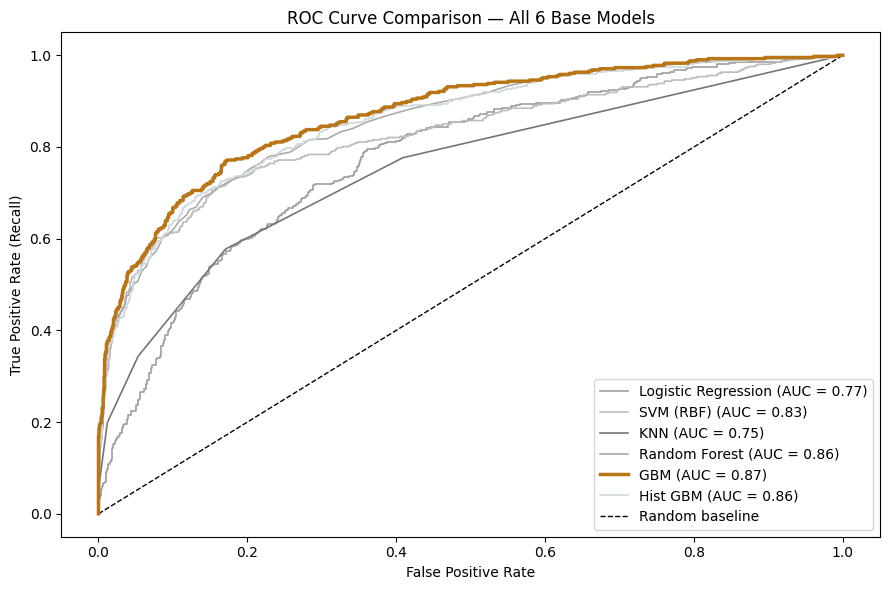

In [14]:
# --- ROC CURVE COMPARISON: ALL 6 BASE MODELS ---
# SVM was initialised with probability=True so predict_proba is available for all models

model_roc_cfg = [
    ('Logistic Regression', log_reg,   X_test_sc, '#9E9E9E', 1.2),
    ('SVM (RBF)',          svm_model, X_test_sc, '#BDBDBD', 1.2),
    ('KNN',                 knn_model, X_test_sc, '#757575', 1.2),
    ('Random Forest',       rf_model,  X_test_sc, '#AAAAAA', 1.2),
    ('GBM',                 gbm_model, X_test_sc, '#BA7517', 2.5),
    ('Hist GBM',            hgb_model, X_test,    '#CFD8DC', 1.2),
]

plt.figure(figsize=(9, 6))

for name, clf, X_t, colour, lw in model_roc_cfg:
    y_prob = clf.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})",
             color=colour, linewidth=lw,
             zorder=3 if name == 'GBM' else 2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline', zorder=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison — All 6 Base Models")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("images/roc_curve_comparison_all_6_base_models.png", dpi=150)
plt.show()

## Step 11: Model Leaderboard — Accuracy vs. Recall
Accuracy tells us how often the model is right overall. Recall tells us how many actual churners we caught. In retention, a missed churner is a lost customer.

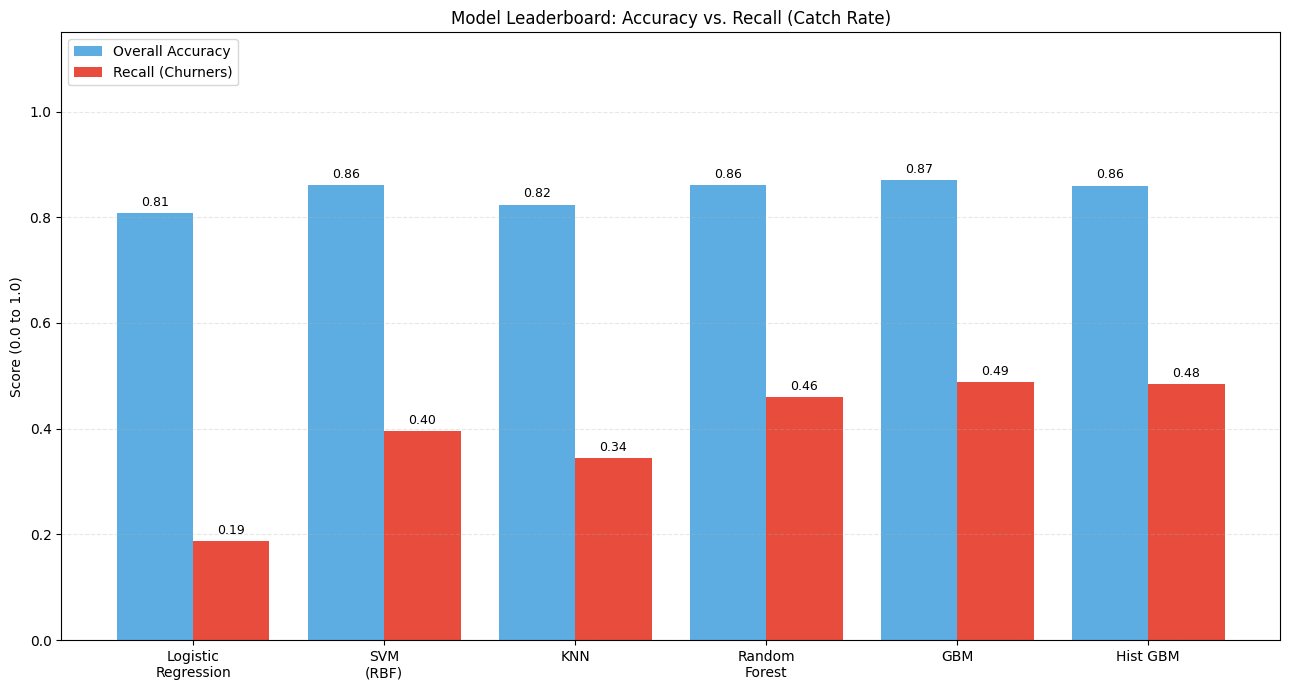

In [15]:
model_names  = ['Logistic\nRegression', 'SVM\n(RBF)', 'KNN',
                'Random\nForest', 'GBM', 'Hist GBM']
preds        = [y_pred_log_reg, y_pred_svm, y_pred_knn,
                y_pred_rf, y_pred_gbm, y_pred_hgb]

acc_scores  = [accuracy_score(y_test, p) for p in preds]
rec_scores  = [recall_score(y_test, p)   for p in preds]

x = np.arange(len(model_names))
fig, ax = plt.subplots(figsize=(13, 7))
b1 = ax.bar(x - 0.2, acc_scores, 0.4, label='Overall Accuracy',    color='#5DADE2')
b2 = ax.bar(x + 0.2, rec_scores, 0.4, label='Recall (Churners)',   color='#E74C3C')
ax.bar_label(b1, padding=3, fmt='%.2f', fontsize=9)
ax.bar_label(b2, padding=3, fmt='%.2f', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel("Score (0.0 to 1.0)")
ax.set_title("Model Leaderboard: Accuracy vs. Recall (Catch Rate)")
ax.set_ylim(0, 1.15)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("images/model_leaderboard_accuracy_vs_recall_catch_rate.png", dpi=150)
plt.show()

## Mitigation Effectiveness — Recall Improvement

Each approach trades a small accuracy reduction for a meaningful gain in churner recall. SMOTE resampling produced the largest improvement, raising recall from 48.9% to 66.3%.

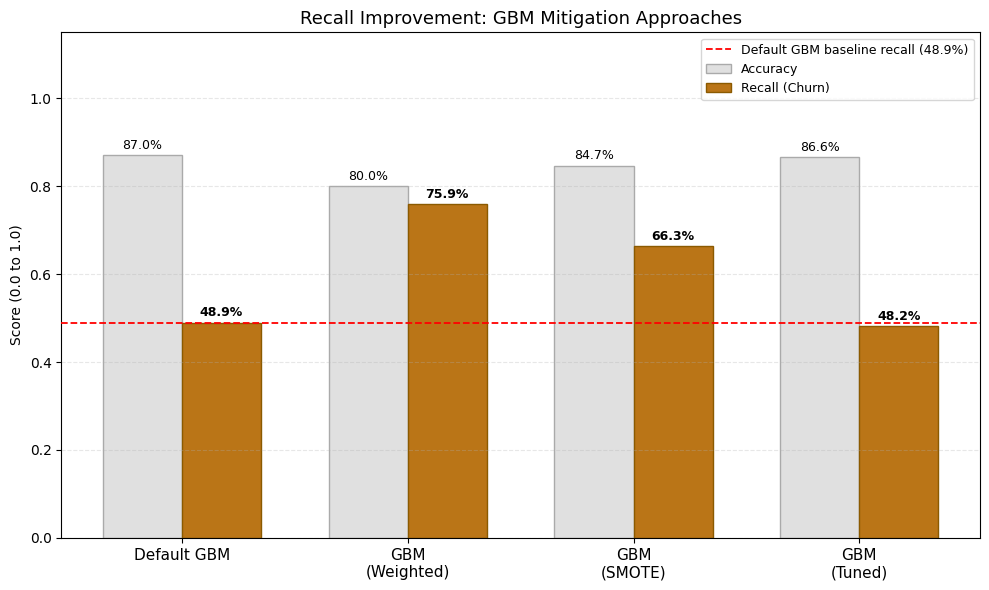

In [16]:
# ── GBM Mitigation Comparison Bar Chart ───────────────────────────────────────
mitigation_names = ['Default GBM', 'GBM\n(Weighted)', 'GBM\n(SMOTE)', 'GBM\n(Tuned)']

mit_acc = [
    accuracy_score(y_test, gbm_model.predict(X_test_sc)),
    accuracy_score(y_test, gb_weighted.predict(X_test_sc)),
    accuracy_score(y_test, gb_smote.predict(X_test_sc)),
    accuracy_score(y_test, best_gbm.predict(X_test_sc)),
]
mit_rec = [
    recall_score(y_test, gbm_model.predict(X_test_sc)),
    recall_score(y_test, gb_weighted.predict(X_test_sc)),
    recall_score(y_test, gb_smote.predict(X_test_sc)),
    recall_score(y_test, best_gbm.predict(X_test_sc)),
]

x = np.arange(len(mitigation_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, mit_acc, width, label='Accuracy',        color='#E0E0E0', edgecolor='#AAAAAA')
b2 = ax.bar(x + width/2, mit_rec, width, label='Recall (Churn)', color='#BA7517', edgecolor='#8B5A00')

# Value labels
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Default GBM recall baseline line
baseline_recall = recall_score(y_test, gbm_model.predict(X_test_sc))
ax.axhline(y=baseline_recall, color='red', linestyle='--', linewidth=1.3,
           label=f'Default GBM baseline recall ({baseline_recall:.1%})', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(mitigation_names, fontsize=11)
ax.set_ylabel("Score (0.0 to 1.0)")
ax.set_title("Recall Improvement: GBM Mitigation Approaches", fontsize=13)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("images/recall_improvement_gbm_mitigation_approaches.png", dpi=150)
plt.show()

## Step 12: Summary Table — All Models at a Glance

In [17]:
# All model variants with their predictions and probability estimates
model_entries = [
    ('Logistic Regression', log_reg,    X_test_sc, y_pred_log_reg),
    ('SVM (RBF)',           svm_model,  X_test_sc, y_pred_svm),
    ('KNN',                 knn_model,  X_test_sc, y_pred_knn),
    ('Random Forest',       rf_model,   X_test_sc, y_pred_rf),
    ('GBM',                 gbm_model,  X_test_sc, y_pred_gbm),
    ('Hist GBM',            hgb_model,  X_test,    y_pred_hgb),
    ('GBM (weighted)',      gb_weighted,X_test_sc, gb_weighted.predict(X_test_sc)),
    ('GBM (SMOTE)',         gb_smote,   X_test_sc, gb_smote.predict(X_test_sc)),
    ('GBM (tuned)',         best_gbm,   X_test_sc, y_pred_best),
]

rows = []
for name, clf, X_t, pred in model_entries:
    rpt = classification_report(y_test, pred, output_dict=True)
    auc = roc_auc_score(y_test, clf.predict_proba(X_t)[:, 1])
    rows.append({
        'Model':              name,
        'Accuracy':           round(accuracy_score(y_test, pred), 4),
        'Recall (Churn)':     round(rpt['1']['recall'], 4),
        'Precision (Churn)':  round(rpt['1']['precision'], 4),
        'F1 (Churn)':         round(rpt['1']['f1-score'], 4),
        'AUC':                round(auc, 4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
display(summary_df
        .sort_values('Recall (Churn)', ascending=False)
        .style.highlight_max(
            subset=['Accuracy', 'Recall (Churn)', 'F1 (Churn)', 'AUC'],
            color='#d5f5e3'))


,Accuracy,Recall (Churn),Precision (Churn),F1 (Churn),AUC
Model,,,,,
GBM (weighted),0.800000,0.759200,0.505700,0.607100,0.869000
GBM (SMOTE),0.847000,0.663400,0.615000,0.638300,0.866900
GBM,0.870000,0.488900,0.792800,0.604900,0.870800
Hist GBM,0.860000,0.484000,0.737800,0.584600,0.856900
GBM (tuned),0.866000,0.481600,0.774700,0.593900,0.867000
Random Forest,0.861000,0.459500,0.763300,0.573600,0.855200
SVM (RBF),0.861000,0.395600,0.834200,0.536700,0.826900
KNN,0.824000,0.344000,0.622200,0.443000,0.753100
Logistic Regression,0.808000,0.186700,0.589100,0.283600,0.774800


## Conclusions & Findings

**Model Selection:** Gradient Boosting achieved the highest accuracy (87.0%) across the six-model benchmark. However, accuracy alone is misleading on this dataset due to class imbalance (~79.6% non-churn). A trivial classifier that predicts "no churn" for every customer would score 79.6% accuracy without identifying a single at-risk customer.

**The Recall Problem:** Default GBM achieved only 48.9% recall on churners — meaning the model missed approximately half of at-risk customers. For a churn use case, this is the metric that matters: a missed churner is a lost customer.

**Mitigation Approaches Tested:**

| Approach | Accuracy | Churner Recall | Notes |
|---|---|---|---|
| Default GBM (baseline) | 87.0% | 48.9% | Class imbalance unaddressed |
| GBM (Sample Weighted) | 80.0% | 75.9% | Highest recall; ~7pp accuracy cost vs default |
| SMOTE resampling | 84.7% | 66.3% | Synthetic minority oversampling on train set only |
| Threshold @ 0.35 | 85.8% | 60.0% | Lower decision boundary, no retraining needed |
| Tuned GBM (GridSearchCV) | 86.6% | 48.2% | Recall-optimised grid search; imbalance still limits gain |

**Key Takeaway:** Sample weighting produced the largest raw recall improvement — from 48.9% to 75.9% — at the cost of approximately 7 percentage points in overall accuracy. For a production retention team with limited capacity to action alerts, SMOTE (66.3% recall, 84.7% accuracy) may offer a better operational balance by generating fewer false positives. The optimal configuration depends on the business's tolerance for false positives: where catching every possible churner is paramount, use weighted GBM; where the retention team needs actionable, high-confidence leads, use SMOTE with a threshold of 0.35.

## Strategic Insight: The "Three-Lens" Framework

When selecting a model for a new project:

1. **Complexity Lens** — Start with Logistic Regression. If it fails, move to tree ensembles (RF → GBM).

2. **Impact Lens (Precision vs. Recall)**
   - High Recall: miss rate is costly (churn, medical diagnosis) → lower the threshold
   - High Precision: false alarm rate is costly (fraud alerts, spam) → raise the threshold

3. **Data Lens**
   - Small / noisy data → Random Forest (more stable)
   - Large / clean data → Gradient Boosting (higher ceiling)
   - Imbalanced labels → always use `stratify=y` and test SMOTE + sample weights